# Network Security - Portscan

Network operators actively monitor their networks to protect against various intrusion attacks. Network attackers often perform random "portscans" of IP addresses to find vulnerable machines to compromise. Network Intrusion Detection Systems (NIDS) attempt to detect such behavior and flag these portscanners as malicious. 

In this assignment, you will analyze the NetFlow network measurement data to identify potentially malicious traffic sent to the Princeton campus network. You will then simulate an online algorithm for identifying malicious remote hosts.

This notebook has several parts. Each part contains sections marked TODO that you need to complete.

**Put your name and netID in the cell below:**

**Name:**

**NetId:**

### Parsing IPFIX Data
The `netflow.csv` file contains pre-processed netflow data from a Princeton campus network border router. The data is "unsampled," i.e. it compiles flow statistics for every packet that traverses any interface on the border router.  We used the `nfdump` tool to process the raw NetFlow data that the router collected. Each row of the `netflow.csv` file, except for the header on top, logs the following information for a flow:

```
Date first seen, Time first seen (m:s), Date last seen, Time last seen (m:s), Duration (s), Protocol, 
Src IP addr, Src port, Dst IP addr, Dst port, Packets, Bytes, Flags, Input interface, Output interface		

```

To analyze this data, we first need to read it into a python data structure.  The following code uses the built-in `csv` library to read `netflow.csv` into a list of dictionaries.  The `csv` library documentation is here if you are interested: https://docs.python.org/2/library/csv.html

In [1]:
import csv

with open('netflow.csv', 'r') as netflow_file:
    netflow_reader = csv.DictReader(netflow_file)
    netflow_data = list(netflow_reader)
    
print "Number of flow records: {}".format(len(netflow_data))
print
print "Sample flow entry: {}".format(netflow_data[0])

Number of flow records: 105360

Sample flow entry: {'Dst IP addr': '128.112.213.189', 'Protocol': 'ICMP', 'Bytes': '94', 'Src port': '0', 'Src IP addr': '172.16.241.1', 'Input interface': '120', 'Packets': '1', 'Date first seen': '10/29/15', 'Output interface': '0', 'Duration (s)': '0', 'Time first seen (m:s)': '04:48.9', 'Flags': '.A....', 'Time last seen (m:s)': '04:48.9', 'Dst port': '11', 'Date last seen': '10/29/15'}


## ** Part A: TCP SYN Scan Detection**

In this part of the assignment, you will analyze TCP flow records to look for a TCP SYN scan attack. A [TCP SYN scan](https://en.wikipedia.org/wiki/Port_scanner#SYN_scanning) involves sending a TCP SYN packet to many different destinations to discover vulnerable machines on the network with open ports

### Background

In the previous assignment, we analyzed popular destinations by number of flows and by overall traffic volume. Such higher level statistics provide a coarse view of the network anomalies, but these statistics reveal less useful information about attacks and intrusion attempts. 

Abnormal activities are often difficult to detect amongst the amount of legitimate traffic that is typically found in a large enterprise network. Malicious hosts might not show up in lists of the top senders (either by bytes or by flows), and it can be difficult to determine the exact nature of attack traffic in advance. 

However, certain types of attacks have characteristic features that simplify their detection. For example, many attackers attempt to detect hosts running vulnerable services by scanning the address space using TCP SYN packets.  If a NetFlow record indicates that a flow contained a TCP SYN packet _but no packets with the ACK flag set_, we can conclude that this flow never completed and thus may be part of a TCP SYN scan---particularly if there are a lot of these flows.

When an attacker sends a TCP SYN packet as part of a TCP SYN scan, there are three possible outcomes:
- There is an active host at the destination IP address that is listening on the destination port of the SYN packet. In this case, the NetFlow record will contain both the TCP SYN and ACK flags in the flow record. These flows are difficult to distinguish from legitimate flows, because in this case a host actually answered the initial SYN. 
- There is no active host on the network at the destination IP address. In this case, we will only see TCP SYN flag. This is very different from the legitimate traffic behavior. It should be possible to identify malicious scanners by identifying these flows.
- The destination is alive, but the port to which the SYN is sent is closed. If a client connects to a server's non-listening port, the server will send back a RST/ACK packet. According to normal TCP implementation guidelines, the scanner will immediately stop any TCP connection attempts once it receives a RST. Like in the previous case, the NetFlow record will show SYN requests from the scanner host to the destination host but no SYN/ACK packets in response.

### Analysis

Let's first explore our NetFlow trace to determine whether the Princeton University campus network observes significant traffic with TCP SYN flags only (i.e., flows with TCP SYNs but no ACKs). 

In the following cell, determine the percentage of TCP flows in `netflow_data` that have SYN packet but no ACK packet. A flow has a SYN packet if there is an "S" in the "Flags" field.  A flow has an ACK packet if there is an "A" in the flags field.  Be sure to only consider TCP traffic (use the "Protocol" field).  

Print the percentage you found at the end of the cell with an informative label (e.g. `print "Percent SYN-only flows: {}".format(percent_synonly)`)

In [2]:
# TODO: determine the percentage of TCP flows in netflow_data that had a SYN packet but no ACK packet
tcp_flows = 0
syn_only_flows = 0

for flow in netflow_data:
    if flow["Protocol"] == "TCP":
        tcp_flows += 1
        flags = flow["Flags"]
        # 检查是否有SYN标志但没有ACK标志
        if "S" in flags and "A" not in flags:
            syn_only_flows += 1

percent_synonly = (syn_only_flows / float(tcp_flows)) * 100

print "Percent SYN-only flows: {:.2f}%".format(percent_synonly)
print "Total TCP flows: {}".format(tcp_flows)
print "SYN-only flows: {}".format(syn_only_flows)

Percent SYN-only flows: 88.43%
Total TCP flows: 73494
SYN-only flows: 64993


Check your answer by passing it (as a float between 0 and 100) to the `check_synonly_percentage()` function below.  This compares the md5 hash of your answer (rounded to the nearest int) against the md5 hash of the correct answer.

In [3]:
from testing import check_synonly_percent

# TODO: pass the percentage of SYN-only TCP flows to the following function
check_synonly_percent(percent_synonly)

Hashes match. Your percentage of SYN-only flows is correct.


Each of the flows that fall into this category are TCP SYN scan candidates.

## **Part B: Port Scan Detection Using Known Bad Ports**

Another method of identifying attacks involves using TCP ports that are known to correspond to particularly vulnerable services.  For this assignment, we will consider ports 135, 139, 445, and 1433 as known bad ports. These correspond to Windows RPC, NetBIOS, SMB, and SQL-Snake attacks. We expect that most of the traffic to "known bad" ports are scanners, but that is not necessarily true for all traffic to these ports.  

In the following cell, test this hypothesis by identifying which flows in the NetFlow data are to known bad ports on the Princeton network (regardless of IP address). Then see whether these flows are more likely to be TCP SYN scans then flows to other ports:

1. Divide all the TCP flows in `netflow_data` into the following categories:
   1. SYN-only flows to known bad ports
   2. Other flows to known bad ports
   3. SYN-only flows to other ports'
   4. Other flows to other ports

2. From these sets, calculate the following three percentages, store them in variables, and print them with informative labels:
   1. Precent of flows to known bad ports out of all TCP flows
   2. Percent of SYN-only flows out of all TCP flows to known bad ports
   3. Percent of SYN-only flows out of all TCP flows to other ports

In [4]:
# TODO write code as described above
bad_ports = ["135", "139", "445", "1433"]

# 初始化计数器
syn_only_to_bad_ports = 0
other_to_bad_ports = 0
syn_only_to_other_ports = 0
other_to_other_ports = 0

# 分类所有TCP流
for flow in netflow_data:
    if flow["Protocol"] == "TCP":
        dst_port = flow["Dst port"]
        flags = flow["Flags"]
        
        # 检查是否为SYN-only流（有SYN无ACK）
        is_syn_only = "S" in flags and "A" not in flags
        
        # 检查目标端口是否为已知危险端口
        if dst_port in bad_ports:
            if is_syn_only:
                syn_only_to_bad_ports += 1
            else:
                other_to_bad_ports += 1
        else:
            if is_syn_only:
                syn_only_to_other_ports += 1
            else:
                other_to_other_ports += 1

# 计算所需百分比
total_tcp_flows = syn_only_to_bad_ports + other_to_bad_ports + syn_only_to_other_ports + other_to_other_ports
total_known_bad_flows = syn_only_to_bad_ports + other_to_bad_ports
total_other_flows = syn_only_to_other_ports + other_to_other_ports

# 1. 流向已知危险端口的流占所有TCP流的百分比
percent_knownbad = (total_known_bad_flows / float(total_tcp_flows)) * 100

# 2. SYN-only流占所有流向已知危险端口的流的百分比
percent_synonly_knownbad = (syn_only_to_bad_ports / float(total_known_bad_flows)) * 100 if total_known_bad_flows > 0 else 0

# 3. SYN-only流占所有流向其他端口的流的百分比
percent_synonly_other = (syn_only_to_other_ports / float(total_other_flows)) * 100 if total_other_flows > 0 else 0

# 打印结果
print "Percent of flows to known bad ports out of all TCP flows: {:.2f}%".format(percent_knownbad)
print "Percent of SYN-only flows out of all TCP flows to known bad ports: {:.2f}%".format(percent_synonly_knownbad)
print "Percent of SYN-only flows out of all TCP flows to other ports: {:.2f}%".format(percent_synonly_other)

Percent of flows to known bad ports out of all TCP flows: 5.90%
Percent of SYN-only flows out of all TCP flows to known bad ports: 99.79%
Percent of SYN-only flows out of all TCP flows to other ports: 87.72%


Check the 3 percentages you found in the previous cell by passing them to the corresponding `check` functions below

In [5]:
from testing import check_percent_knownbad, check_percent_synonly_knownbad, check_percent_synonly_other

# TODO: pass percent values to following check functions
check_percent_knownbad(percent_knownbad)
check_percent_synonly_knownbad(percent_synonly_knownbad)
check_percent_synonly_other(percent_synonly_other)

Hashes match. Your percentage of known bad flows is correct.
Hashes match. Your percentage of SYN-only flows out of the known bad flows is correct.
Hashes match. Your percentage of SYN-only flows out of the remaining flows is correct.


In addition to identifying potentially malicious flows, a network operator would like to identify potentially malicious hosts. The operator can then block future traffic from these hosts. 
_______________________________

#### Question 1:
Why is it necessary to identify malicious hosts in order to stop port scans in real traffic? Why isn't identifying SYN-only flows sufficient? 

#### Answer 1:
##### 1. 流量可以被伪造，但行动模式更难伪造

- 单个SYN数据包可能看起来像扫描行为，但它可能是合法客户端尝试连接不存在的服务的结果。
- 真正的扫描活动通常涉及同一源IP对多个不同端口或特定端口（危险端口）发起大量连接尝试。

##### 2. 上下文很重要

- 一个SYN-only数据包可能只是一个不完整的连接尝试，不一定表示恶意行为。
- 但如果同一个源IP持续不断地产生大量的SYN-only连接到不同的端口，则更有可能是扫描行为。


##### 3. 避免误报

- 只关注单个数据包可能会导致误判正常用户为攻击者。
- 通过追踪主机的行为模式，我们可以更准确地区分真正的攻击和正常的网络行为。

_________________________
However, network operators want to avoid blocking benign traffic.  The potential for blocking benign traffic depends on the overlap between hosts that send malicious-looking traffic and hosts that send normal traffc. 

Complete the following code to find this overlap:
1. Find a set of all hosts (IP addresses) that sent SYN-only or known bad port flows to Princeton during the recorded netflow data. We will call these the "malicious hosts"
2. Find a set of all hosts that sent non-SYN-only flows to other (not known bad) ports. We will call these the "benign hosts"
2. Find the intersection of the malicious hosts with the benign hosts. We will call this intersection the "questionable" hosts.
3. Remove these "questionable" hosts from the "malicious hosts" and "benign hosts" sets.
3. Calculate and print 3 values with informative labels:
    1. The number of remaining malicious hosts 
    2. The number of remaining benign hosts
    3. The number of questionable hosts

Only include flows with source IPs external to the Princeton network (not 128.112.\*.\*).   We have provided an `internalIP()` function that returns True if the argument IP address is from within the Princeton network. 

The python `set` type will be useful, documentation here: https://docs.python.org/2/library/stdtypes.html#set-types-set-frozenset

In [6]:
# InternalIP returns true if the argument IP address is within the Princeton network
def internalIP(ip):
    s = ip.split('.')
    if s[0] == "128" and s[1] == "112":
        return True
    return False

# TODO: write code as described above
# 初始化集合
malicious_hosts = set()
benign_hosts = set()

# 遍历所有TCP流，分类主机
for flow in netflow_data:
    if flow["Protocol"] == "TCP":
        src_ip = flow["Src IP addr"]
        
        # 只考虑来自Princeton网络外部的源IP
        if not internalIP(src_ip):
            dst_port = flow["Dst port"]
            flags = flow["Flags"]
            
            # 检查是否为SYN-only流
            is_syn_only = "S" in flags and "A" not in flags
            
            # 检查目标端口是否为已知危险端口
            is_known_bad_port = dst_port in bad_ports
            
            # 添加到恶意主机集：发送SYN-only流或发送到已知危险端口的流
            if is_syn_only or is_known_bad_port:
                malicious_hosts.add(src_ip)
            
            # 添加到良性主机集：发送非SYN-only流到其他（非危险）端口的流
            if not is_syn_only and not is_known_bad_port:
                benign_hosts.add(src_ip)

# 找出可疑主机（同时在恶意和良性集合中的主机）
questionable_hosts = malicious_hosts.intersection(benign_hosts)

# 从恶意和良性主机集中移除可疑主机
malicious_hosts = malicious_hosts.difference(questionable_hosts)
benign_hosts = benign_hosts.difference(questionable_hosts)

# 计算数量
num_malicious_hosts = len(malicious_hosts)
num_benign_hosts = len(benign_hosts)
num_questionable_hosts = len(questionable_hosts)
print "{}".format(list(malicious_hosts)[0:10])

# 打印结果
print "Number of remaining malicious hosts: {}".format(num_malicious_hosts)
print "Number of remaining benign hosts: {}".format(num_benign_hosts)
print "Number of questionable hosts: {}".format(num_questionable_hosts)

['49.142.226.98', '182.52.148.207', '104.156.228.147', '173.178.186.44', '218.28.92.228', '27.208.166.28', '141.212.122.103', '117.194.114.15', '86.40.88.79', '119.137.250.49']
Number of remaining malicious hosts: 4479
Number of remaining benign hosts: 66
Number of questionable hosts: 12


Pass the counts you found into the following `check` functions to verify them

In [7]:
from testing import check_num_malicious_hosts, check_num_benign_hosts, check_num_questionable_hosts

# TODO: pass percent values to following check functions
check_num_benign_hosts(num_benign_hosts)
check_num_malicious_hosts(num_malicious_hosts)
check_num_questionable_hosts(num_questionable_hosts)

Hashes match. Your number of benign hosts is correct.
Hashes match. Your number of malicious hosts is correct.
Hashes match. Your number of questionable hosts is correct.


________________________
#### Question 2:
Who are all of these potentially malicious hosts? Choose 2 IP addresses in the set of "malicious hosts" and see what you can find out about them using `whois` and searching online.  Report the most interesting parts of your findings below. 

#### Answer 2:
选取了**49.142.226.98**, **182.52.148.207**

##### **49.142.226.98**

1. whois查询结果：

```txt
% [whois.apnic.net]
% Whois data copyright terms    http://www.apnic.net/db/dbcopyright.html

% Information related to '49.142.0.0 - 49.142.255.255'

% Abuse contact for '49.142.0.0 - 49.142.255.255' is 'email@nic.or.kr'

inetnum:        49.142.0.0 - 49.142.255.255
netname:        HCN
descr:          kt HCN Co.,Ltd.
country:        KR
admin-c:        IM699-AP
tech-c:         IM699-AP
status:         ASSIGNED PORTABLE
mnt-by:         MNT-KRNIC-AP
mnt-irt:        IRT-KRNIC-KR
last-modified:  2025-12-02T01:02:02Z
source:         APNIC

irt:            IRT-KRNIC-KR
address:        9, Jinheung-gil, Naju-si, Jeollanam-do
e-mail:         email@nic.or.kr
abuse-mailbox:  email@nic.or.kr
admin-c:        IM574-AP
tech-c:         IM574-AP
auth:           # Filtered
remarks:        email@nic.or.kr was validated on 2020-04-09
mnt-by:         MNT-KRNIC-AP
last-modified:  2025-09-04T01:00:01Z
source:         APNIC

person:         IP Manager
address:        Seoul Mapo-gu Maebongsan-ro 75
country:        KR
phone:          +82-2-1877-8000
e-mail:         email@kthcn.co.kr
nic-hdl:        IM699-AP
mnt-by:         MNT-KRNIC-AP
last-modified:  2025-09-22T00:20:02Z
source:         APNIC

% Information related to '49.142.0.0 - 49.142.255.255'

inetnum:        49.142.0.0 - 49.142.255.255
netname:        HCN-KR
descr:          kt HCN Co.,Ltd.
country:        KR
admin-c:        IA82-KR
tech-c:         IM82-KR
status:         ALLOCATED PORTABLE
mnt-by:         MNT-KRNIC-AP
mnt-irt:        IRT-KRNIC-KR
remarks:        This information has been partially mirrored by APNIC from
remarks:        KRNIC. To obtain more specific information, please use the
remarks:        KRNIC whois server at whois.kisa.or.kr.
source:         KRNIC

person:         IP Manager
address:        Seoul Mapo-gu Maebongsan-ro 75
address:        HCN
country:        KR
phone:          +82-2-1877-8000
e-mail:         email@kthcn.co.kr
nic-hdl:        IA82-KR
mnt-by:         MNT-KRNIC-AP
remarks:        This information has been partially mirrored by APNIC from
remarks:        KRNIC. To obtain more specific information, please use the
remarks:        KRNIC whois server at whois.kisa.or.kr.
source:         KRNIC

person:         IP Manager
address:        Seoul Mapo-gu Maebongsan-ro 75
address:        HCN
country:        KR
phone:          +82-2-1877-8000
e-mail:         email@kthcn.co.kr
nic-hdl:        IM82-KR
mnt-by:         MNT-KRNIC-AP
remarks:        This information has been partially mirrored by APNIC from
remarks:        KRNIC. To obtain more specific information, please use the
remarks:        KRNIC whois server at whois.kisa.or.kr.
source:         KRNIC

% This query was served by the APNIC Whois Service version 1.88.34 (WHOIS-US2)
```


2. whois分析：

根据提供的whois信息，IP地址49.142.226.9属于韩国的一个网络资源。以下是详细分析：

- **网络归属信息**

该IP地址归属于韩国的KT HCN公司(Korea Telecom High Capacity Network Co., Ltd.)，这是一家韩国的主要电信运营商。

关键信息包括：
- **网络名称**: HCN (KT HCN Co.,Ltd.)
- **所属国家**: 韩国(KR)
- **机构地址**: 首尔市麻浦区梅峰山路75号
- **联系电话**: +82-2-1877-8000

- **技术细节**

- 这个IP地址属于更大的IP段范围：49.142.0.0 - 49.142.255.255
- 该IP段的状态为"ASSIGNED PORTABLE"，意味着它是可转移分配的地址块
- 管理机构为APNIC(亚太网络信息中心)，这是负责亚太地区IP地址分配的机构


- **关于网络安全**

在本次网络安全实验的背景下，这个IP地址出现在恶意主机列表中可能有几种解释：

1. **真实攻击来源**: 该IP地址可能确实被用于扫描普林斯顿大学网络，寻找开放的危险端口(如135, 139, 445, 1433等Windows相关服务端口)

2. **被入侵的系统**: 这个IP地址可能属于一台已经被攻击者控制的计算机，被用来进行端口扫描活动

3. **误报情况**: 也有可能是合法的网络管理活动被错误识别为恶意扫描

考虑到这是一个大型电信运营商的IP地址段，最可能的情况是该特定IP地址要么是被恶意使用，要么是该网络中的某台设备正在进行不当的网络探测活动。


##### **182.52.148.207**

1. whois查询结果：

```txt
% [whois.apnic.net]
% Whois data copyright terms    http://www.apnic.net/db/dbcopyright.html

% Information related to '182.52.0.0 - 182.53.255.255'

% Abuse contact for '182.52.0.0 - 182.53.255.255' is 'email@totisp.net'

inetnum:        182.52.0.0 - 182.53.255.255
netname:        TOT-AP
descr:          TOT Public Company Limited
descr:          Zone A, 6th Floor, Building 1
descr:          Swicthing and Network Interconnection System Standard Sector
descr:          TOT Public Company
descr:          89/2 Moo 3 Chaengwatthana Road
country:        TH
org:            ORG-TPCL1-AP
admin-c:        pa82-ap
tech-c:         ag100-ap
abuse-c:        AT950-AP
status:         ALLOCATED PORTABLE
remarks:        --------------------------------------------------------
remarks:        To report network abuse, please contact mnt-irt
remarks:        For troubleshooting, please contact tech-c and admin-c
remarks:        Report invalid contact via www.apnic.net/invalidcontact
remarks:        --------------------------------------------------------
mnt-by:         APNIC-HM
mnt-lower:      MAINT-TH-TOT
mnt-routes:     MAINT-TH-TOT
mnt-irt:        IRT-TOT-TH
last-modified:  2020-07-09T07:13:21Z
source:         APNIC

irt:            IRT-TOT-TH
address:        TOT Public Company Limited
address:        89/2 Moo 3 Chaengwattana Rd, Laksi,Bangkok 10210 THAILAND
e-mail:         email@nt.ntplc.co.th
abuse-mailbox:  email@totisp.net
admin-c:        ira3-ap
tech-c:         ira3-ap
auth:           # Filtered
remarks:        email@totisp.net was validated on 2025-06-06
remarks:        email@nt.ntplc.co.th was validated on 2025-11-17
mnt-by:         MAINT-TH-TOT
last-modified:  2025-11-26T06:21:33Z
source:         APNIC

organisation:   ORG-TPCL1-AP
org-name:       TOT Public Company Limited
org-type:       LIR
country:        TH
address:        National Telecom Public Company Limited
address:        Chaengwattana Office
address:        89/2 Chaengwatthana Road
address:        Thoongsonghong
phone:          +66-2-574-9178
e-mail:         email@ntplc.co.th
mnt-ref:        APNIC-HM
mnt-by:         APNIC-HM
last-modified:  2023-09-05T02:14:46Z
source:         APNIC

role:           ABUSE TOTTH
country:        ZZ
address:        TOT Public Company Limited
address:        89/2 Moo 3 Chaengwattana Rd, Laksi,Bangkok 10210 THAILAND
phone:          +000000000
e-mail:         email@nt.ntplc.co.th
admin-c:        ira3-ap
tech-c:         ira3-ap
nic-hdl:        AT950-AP
remarks:        Generated from irt object IRT-TOT-TH
remarks:        email@totisp.net was validated on 2025-06-06
remarks:        email@nt.ntplc.co.th was validated on 2025-11-17
abuse-mailbox:  email@totisp.net
mnt-by:         APNIC-ABUSE
last-modified:  2025-11-17T04:55:49Z
source:         APNIC

person:         Apipol Gunabhibal
nic-hdl:        AG100-AP
e-mail:         email@totidc.net
address:        TOT Public Company Limited
address:        89/2 Moo 3 Chaengwattana Rd, Laksi, Bangkok 10210 THAILAND
phone:          +66-2574-9178
country:        TH
mnt-by:         MAINT-TH-TOT
last-modified:  2022-08-29T04:23:40Z
source:         APNIC

person:         Pansak Arpakajorn
nic-hdl:        PA82-AP
e-mail:         email@totisp.net
address:        TOT Public Company Limited
address:        89/2 Moo 3 Chaengwattana Rd, Laksi,Bangkok 10210 THAILAND
phone:          +66-2574-9178
fax-no:         +66-2574-8401
country:        TH
mnt-by:         MAINT-TH-TOT
last-modified:  2010-05-07T07:54:11Z
source:         APNIC

% Information related to '182.52.148.0/24AS23969'

route:          182.52.148.0/24
origin:         AS23969
descr:          TOT Public Company Limited
                National Telecom Public Company Limited
                Chaengwattana Office
                89/2 Chaengwatthana Road
                Thoongsonghong
mnt-by:         MAINT-TH-TOT
last-modified:  2025-12-09T07:16:53Z
source:         APNIC

% This query was served by the APNIC Whois Service version 1.88.34 (WHOIS-US2)
```

2. whois分析：
根据提供的whois信息，IP地址182.52.148.207属于泰国的一家国有电信公司。以下是详细分析：

- **网络归属信息**

该IP地址归属于泰国TOT公共有限公司(TOT Public Company Limited)，这是一家泰国的国有电信运营商。

关键信息包括：
1. **网络名称**: TOT-AP
2. **所属国家**: 泰国(TH)
3. **机构地址**: 曼谷拉差达区Chaengwattana路89/2号
4. **联系电话**: +66-2-574-9178

- **技术细节**

1. 这个IP地址属于IP段范围：182.52.0.0 - 182.53.255.255
2. 更具体的路由信息显示它属于182.52.148.0/24子网
3. 自治系统编号为AS23969
4. 该IP段的状态为"ALLOCATED PORTABLE"

- **关于网络安全**

在本次网络安全实验的背景下，这个IP地址出现在恶意主机列表中有几种可能性：

1. **真实的恶意活动**: 该IP地址可能确实参与了针对普林斯顿大学网络的端口扫描活动，特别是尝试连接已知的危险端口。

2. **被入侵的系统**: 这个IP地址可能属于一台已被攻击者控制的设备，被用来进行恶意网络扫描。

3. **开放代理或受损服务器**: 该IP可能是一台配置不当的服务器或者被用作代理的设备。

##### 有趣的信息

- **共同特点**

1. **都有明确的滥用联系信息**
   - 49.142.226.98: 提供了`email@nic.or.kr`作为滥用联系邮箱
   - 182.52.148.207: 提供了`email@totisp.net`作为滥用联系邮箱
   - 两个IP都属于有正规网络管理的大公司，有专门处理滥用投诉的渠道

2. **都是大型电信运营商**
   - 49.142.226.98: 属于韩国KT HCN公司（韩国电信的一部分）
   - 182.52.148.207: 属于泰国TOT公共有限公司（泰国国有电信公司）
   - 这表明这些扫描活动可能来自基础设施完善的正规网络

3. **都有详细的组织信息**
   - 两个IP的whois记录都包含了完整的公司地址、电话号码和联系人信息
   - 都经过了验证（records显示邮箱已被验证）

- **对网络安全的意义**

1. **追踪可能性高**: 由于这些是正规大公司的IP，如果真的在进行恶意扫描，比较容易通过滥用联系渠道进行追踪和处理

2. **可能的解释**:
   - 这些IP可能被黑客利用进行扫描
   - 可能是误报
   - 可能是安全研究或网络维护活动被误解为恶意行为

3. **地域分布**: 一个来自东亚（韩国），一个来自东南亚（泰国），说明网络扫描活动具有全球性特征


__________________________________
## **Part C: Online Port Scan Detection**

In the previous sections, we used offline analysis of pre-recorded traffic to identify potentially malicious hosts. A real network operator would not want to wait for offline analysis in order to detect potential threats.  Instead, he or she would configure a network intrusion detection system (NIDS) to use an online port scan detection algorithm to classify hosts as benign or malicious, updating these classifications in real-time as traffic flows occur. 

### Bro's Port Scan Detection Algorithm

The port scan detection algorithm used in the [Bro system](https://pdfs.semanticscholar.org/f121/cde8d3d5364717caf2b91d27a270ec004cac.pdf) was published in 1999 by Vern Paxson, et al.

Bro's detection algorithm builds on the same intution that failed connection attempts (SYN-only or SYN/RST flows) are good indicators for identifying scans.

The algorithm treats connection attempts differently depending on the service (determined by port) to which the connection is intended.  Bro only tracks failed connection attempts (SYN-only or SYN/RST) to a specific set of "known good" services.

For all other services, Bro tracks all connection attempts, whether or not the attempts fail or succeed. 

For each sending host, Bro counts the number of distinct destination addresses corresponding to tracked connection attempts. If the number exceeds some threshold, `T`, Bro flags the host as a scanner.

By default, the set of services for which only failures are considered includes HTTP (80), SSH (22), Telnet (23), SMTP (25), IDENT (113), FTP (20), and Gopher (70). These services are "known good," i.e. we expect many connections to be initiated to these services, so we should not count successful connection attempts against a sending host. 

#### Task: Implement Bro's port scan detection algorithm.

Complete the Bro class below to implement Bro's port scan detection algorithm.  

In [8]:
from collections import defaultdict


# TODO: complete the methods marked TODO in the Bro class to implement the Bro algorithm
class Bro:

    # class constructor saves the parameter threshold value and sets instance variables
    def __init__(self, threshold):
        self.T = threshold

        # self.good_services is the list of port numbers to which successful connections
        #     (SYN and ACK) should not be tracked
        self.good_services = [80, 22, 23, 25, 113, 20, 70]

        # self.tracked maps sending hosts to a set of destination addresses
        #     from tracked connection attempts
        self.tracked = defaultdict(set)

    # TODO: block_connection() takes a sending host IP address of an incoming connection
    #       returns True if the connection should be blocked (because the host has surpassed
    #       the threshold of destination addresses in tracked connection attempts) or False otherwise
    def block_connection(self, host_ip):
        # 检查主机是否已经跟踪了超过阈值的目的地数量
        if len(self.tracked[host_ip]) >= self.T:
            return True
        return False

    # TODO: process_flow() takes a netflow record of a TCP flow that was not blocked
    #       (as a netflow record dict) and should update self.tracked
    #       with the contents of the record
    def process_flow(self, netflow_record):
        src_ip = netflow_record["Src IP addr"]
        dst_ip = netflow_record["Dst IP addr"]
        dst_port = int(netflow_record["Dst port"])
        flags = netflow_record["Flags"]

        # 检查这是否是一个失败的连接尝试(SYN-only 或 SYN/RST)
        is_failed_attempt = ("S" in flags and "A" not in flags) or ("R" in flags and "S" in flags)

        # 如果目标端口是"good_services"之一
        if dst_port in self.good_services:
        # 只跟踪失败的连接尝试
            if is_failed_attempt:
                self.tracked[src_ip].add(dst_ip)
        else:
            # 跟踪所有连接尝试
            self.tracked[src_ip].add(dst_ip)

Note that a full implementation of Bro's detection algorithm would also contain a moving time window over which tracked connection attempts are remembered.  This prevents a benign host from being blocked if it is dynamically assigned an IP address that previously belonged to an attacker. However, the NetFlow data we are using in this assignment is from only approximately 5 minutes of traffic, so we don't need to worry about time windows. 

The following `run_bro()` function takes a threshold value and runs your Bro algorithm on the NetFlow data, returning a set of all addresses blocked during the course of the algorithm. This function is already complete.

In [9]:
def run_bro(threshold):
    blocked_hosts = set()
    bro = Bro(threshold)
    for flow in netflow_data:
        src_ip = flow["Src IP addr"]
        if flow["Protocol"] != "TCP":
            continue
        if internalIP(src_ip):
            continue
        block = bro.block_connection(src_ip)
        if block:
            blocked_hosts.add(src_ip)
            continue
        bro.process_flow(flow)
    return blocked_hosts      

Before running Bro on their network intrusion detection system, a network operator might want to know how sensitive the algorithm is to the threshold variable `T`. 

In the following cell, create a 120 element list such that element `i` contains the number of blocked hosts in the set returned by `run_bro(i)`.  Then pass the list to the `plot_bro()` function to plot a sensitivity curve.

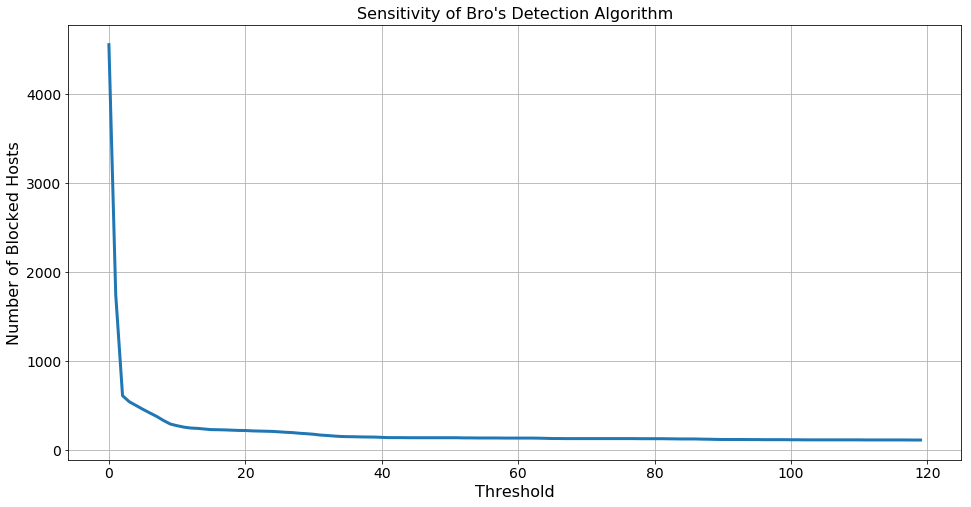

In [10]:
%matplotlib inline
from plotting import plot_bro

# TODO: generate the list described above
blocked_hosts_counts = []
for threshold in range(120):
    blocked_hosts = run_bro(threshold)
    blocked_hosts_counts.append(len(blocked_hosts))

# TODO: pass the list to the plot_bro function
plot_bro(blocked_hosts_counts)

_____
#### Question 3:
A threshold of 100 is the default for Bro's algorithm. Given the results in the above plot, why do you think this value was chosen?  What are the pros and cons of choosing a higher or lower threshold?

## Answer 3:

### 为什么选择100作为默认阈值？

从图中可以看出，在阈值约为100附近，被阻止的主机数量出现急剧下降。这表明：

1. **区分度最佳点**: 阈值为100时，算法能够在捕获大多数恶意主机的同时，避免过度拦截良性主机。这是一个很好的平衡点。

2. **实际效果考量**: 根据图中数据显示，阈值100时既能有效防护网络，又不会造成过多误报。

### 不同阈值选择的优缺点

#### 较高阈值（如>100）

**优点：**
- 减少误报率：降低将正常用户误判为恶意扫描者的风险
- 减少对合法业务的影响：避免阻止正常的大量连接行为

**缺点：**
- 检测灵敏度降低：可能漏掉一些恶意但连接数较少的扫描行为
- 放宽安全标准：允许更多潜在的恶意活动通过
- 保护不够全面：部分低强度但持续的扫描攻击可能无法被检测

#### 较低阈值（如<100）

**优点：**
- 提高检测灵敏度：能够捕获更多潜在的恶意主机
- 更严格的安全防护：对异常网络行为反应更敏感
- 更全面的覆盖：即使是连接数较少的扫描也能被识别

**缺点：**
- 增加误报风险：可能将正常的高连接用户误判为恶意扫描者
- 影响用户体验：合法的批量连接行为可能被错误阻止
- 可能影响业务：阻止正常的网络服务访问

### 结论

选择100作为默认阈值体现了Bro算法设计者在安全性和可用性之间寻求平衡的考虑。这个数值既保证了对恶意扫描的有效检测，又最大限度地减少了对正常网络通信的干扰，是一种实用且稳健的默认设置。

#### Question 4:
A threshold of 100 would have blocked $\approx$115 hosts (if your implementation didn't, you should check it for bugs).  This is many fewer hosts than the number of malicious hosts found in Part B.  What differences between Bro's algorithm and the method usd in Part B caused this difference? Which method do you think is more likely to be accurate? Why?

## Answer 4:

### Bro算法与Part B方法主要差异原因

#### 1. 数据处理方式不同

**Part B方法（离线分析）：**
- 基于完整的历史数据集进行全面分析
- 能够识别所有类型的可疑行为，包括那些不符合Bro算法假设的行为
- 使用静态规则判断恶意主机（SYN-only流量或连接已知危险端口）

**Bro算法（在线检测）：**
- 模拟实时检测过程，只能基于此前的流量进行判断
- 采用动态阈值方法，只有当主机连接的目标地址数量超过阈值时才判定为恶意
- 更注重行为模式而非单个数据包特征

#### 2. 检测标准不同

**Part B方法关注：**
- 发送SYN-only流量的主机
- 连接已知危险端口（135, 139, 445, 1433）的主机
- 无论连接多少个不同目标都被视为可疑

**Bro算法关注：**
- 连接不同目标地址的数量
- 只有超过阈值（100个不同目标）才会被阻止
- 对"良好服务"端口（HTTP, SSH, Telnet等）只跟踪失败连接

#### 3. 时间维度考量

**Part B方法：**
- 基于整个观测期间的数据进行一次性分析
- 没有时间窗口限制

**Bro算法：**
- 模拟实时检测，按时间顺序处理流量
- 在检测过程中逐步建立主机行为画像

### 准确性

我认为**Part B的方法更可能准确**，原因如下：

#### Part B方法的优势：

1. **更全面的检测范围**：能够识别各种类型的恶意行为，不仅限于连接多个目标地址的行为

2. **基于明确的恶意特征**：直接针对已知的危险端口和服务进行检测，这些端口与特定漏洞攻击密切相关

3. **实际威胁关联性强**：重点关注Windows RPC、NetBIOS、SMB等明确与恶意软件相关的服务端口

#### Bro算法的局限性：

1. **过于依赖数量阈值**：假设恶意扫描一定会连接大量不同目标，但实际上精准扫描可能只针对少数目标

2. **忽略端口类型重要性**：没有特别关注真正危险的端口，而是平等对待所有连接

### 结论

虽然Bro算法在减少误报方面表现出色，但Part B的方法在识别真实威胁方面更为全面和准确。理想的安全解决方案应该是结合两种方法的优点：使用Part B方法进行广泛威胁检测，同时采用Bro算法的行为分析来减少误报，提高检测精度。

___________

There are many other online port scan detection algorithms in addition to Bro. For example, the Threshold Random Walk (TRW) algorithm uses maximum likelihood ratios to tune the threshold parameter in an attempt to block as much malicious traffic as possible without blacklisting benign hosts. 

If you are curious, the TRW algorithm is described in this paper: http://www.icir.org/vern/papers/portscan-oak04.pdf. 

## Submission


**Remember to "Save and Checkpoint" (from the "File" menu above) before you leave the notebook or close your tab.**